In [7]:
from functools import partial

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from integral_functions.weight_functions import (
    get_weights_densities,
    get_points_in_interval,
    get_interval_population_density,
)
from integral_functions.methods.inducing_points import (
    get_discretizations,
    midpoint_to_disc,
)
from numpy.typing import NDArray
from scipy.special import expit
from scipy.integrate import quad
from sklearn.metrics import mean_absolute_error, mean_squared_error
import statsmodels.api as sm

from regmod.models.binomial import BinomialModel
from regmod.parameter import Parameter
from regmod.variable import Variable
# from msca.integrate.integration_weights import build_integration_weights

# For more Cython info on the import statement, visit the link: https://stackoverflow.com/questions/7508803/how-do-i-import-function-from-pyx-file-in-python

from integral_functions.methods.inducing_points import get_discretizations
from integral_functions.simulation.age_distribution import age_distribution
from integral_functions.simulation.death_rate import (
    death_rate_function,
    expit_death_rate_function,
    func1,
    func2,
    func3,
)
from integral_functions.simulation.sampling import sample_probability_of_death, probability_of_death_no_error
from integral_functions.simulation.age_intervals import (
    bounded_intervals_generator,
    int_bounded_intervals_generator,
    pop_density_generator,
)
from integral_functions.simulation.integrate_functions import (
    integrate_cov,
    integrate_denom,
)
from integral_functions.simulation.data_generator import (
    simulation_data_generator,
    estimation_dataframe,
)

#### Uniform 1-year age groups

In [8]:
low_age = 0
high_age = 95
age_mid = 35

c1 = 0.001
c2 = 1
c3 = 0.0017

grid_points = np.arange(start=(low_age + 0.5), stop=(high_age + 0.5), step=1)

# range for each sample group
np.random.seed(0)
num_groups = 1000
age_interval_lb = 15
age_interval_ub = 20
sample_size_low = 10
sample_size_high = 100
prob_args = {"c1": c1}

expit_death_rate_function = partial(expit_death_rate_function, c1 = c1, c2 = c2, c3 = c3)

In [3]:
df = simulation_data_generator(
    low_age=low_age,
    high_age=high_age,
    num_groups=num_groups,
    age_interval_lb=age_interval_lb,
    age_interval_ub=age_interval_ub,
    sample_size_low=sample_size_low,
    sample_size_high=sample_size_high,
    prob_args=prob_args,
    mid_age=age_mid,
    sample_error=False
)

df_dense, df_sparse = estimation_dataframe(df=df, grid_points=grid_points)

In [4]:
df_sparse.head()

,age_start,age_end,sample_size,obs,cov1,cov2,cov3,outcomes
0,44,60,29,0.077510,51.420149,-7.163688,2665.012246,0.070322
1,47,64,49,0.113321,54.812803,-7.396313,3028.065111,0.100310
2,64,79,49,0.544060,70.806754,-8.410854,5031.877966,0.553333
3,67,84,71,0.681428,74.539789,-8.629148,5579.442397,0.717165
4,67,82,54,0.658168,73.766158,-8.585139,5459.681179,0.683539


In [16]:
sample_probability_of_death(44, 60, 29, age_distribution, expit_death_rate_function, prob_args=prob_args)

[0.55291231 0.67127706 0.04991886 0.63407662 0.40044337 0.03270906
 0.58254385 0.85295486 0.92668545 0.43280983 0.07936775 0.57271592
 0.45564002 0.87454273 0.56670913 0.82236925 0.61982655 0.66782116
 0.18558124 0.45156721 0.10766136 0.17880541 0.35687819 0.74491202
 0.01744171 0.8057578  0.76299009 0.42662256 0.27780324]


0.10344827586206896

In [9]:
expit_death_rate_function((60 + 44)/2)

0.07160432418491584

In [5]:
probability_of_death_no_error(44, 60, age_distribution, expit_death_rate_function, age_mid)

0.07751025760665006

In [6]:
model_discrete_1 = BinomialModel(
    y="obs",
    weights="sample_size",
    df=df,
    params=[
        Parameter(
            "p", [Variable(f"cov{i + 1}") for i in range(3)], inv_link="expit"
        )
    ],
)

In [7]:
model_discrete_1.fit()

In [8]:
model_discrete_1.opt_result.x

array([8.22037043e-02, 1.29587599e+00, 1.03756597e-03])

In [9]:
df_pred = pd.DataFrame(dict(age_mid=np.linspace(low_age, high_age, 101)))
df_pred["cov1"] = func1(df_pred["age_mid"])
df_pred["cov2"] = func2(df_pred["age_mid"])
df_pred["cov3"] = func3(df_pred["age_mid"])
df_pred = model_discrete_1.predict(df_pred)
df_pred["p_true"] = expit_death_rate_function(df_pred["age_mid"], c1=c1)

In [10]:
df_pred

,age_mid,cov1,cov2,cov3,p,p_true
0,0.00,0.00,-0.000000,0.0000,0.500000,0.500000
1,0.95,0.95,-0.974679,0.9025,0.234328,0.274443
2,1.90,1.90,-1.378405,3.6100,0.164337,0.202560
3,2.85,2.85,-1.688194,8.1225,0.125102,0.158219
4,3.80,3.80,-1.949359,14.4400,0.099861,0.127749
...,...,...,...,...,...,...
96,91.20,91.20,-9.549869,8317.4400,0.977055,0.990815
97,92.15,92.15,-9.599479,8491.6225,0.981034,0.992814
98,93.10,93.10,-9.648834,8667.6100,0.984368,0.994399
99,94.05,94.05,-9.697938,8845.4025,0.987152,0.995650


Text(0.5, 1.0, 'Discrete weights uniform spacing = 1')

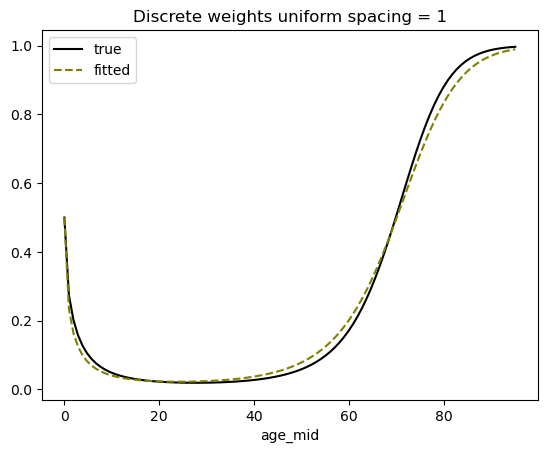

In [11]:
fig, ax = plt.subplots()
ax.plot(df_pred["age_mid"], df_pred["p_true"], color="k", label="true")
ax.plot(
    df_pred["age_mid"],
    df_pred["p"],
    color="olive",
    linestyle="--",
    label="fitted",
)
ax.legend()
ax.set_xlabel("age_mid")
# ax.set_yscale("log")
plt.title("Discrete weights uniform spacing = 1")

# for _, row in df.iterrows():
#     ax.plot([row["age_start"], row["age_end"]], [row["obs"]]*2, color="grey", alpha=0.2)

#### Uniform 5-year age groups

In [18]:
low_age = 0
high_age = 95
age_mid = 35

c1 = 0.001
c2 = 1
c3 = 0.0017

step = 5

# Make sure to go above high_age by just a little bit on the grid_point construction
grid_points = np.arange(
    start=(low_age + 2.5), stop=(high_age + step + 0.5), step=step
)
# discretizations = get_discretizations(
#     low_age, high_age, grid_points=grid_points
# )
# My construction of this right now implies that we want population_densities to be equal in shape to grid_points. Basically we want the
# age density to be as fine as the number of grid points we have.

In [19]:
grid_points

array([ 2.5,  7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5, 42.5, 47.5, 52.5,
       57.5, 62.5, 67.5, 72.5, 77.5, 82.5, 87.5, 92.5, 97.5])

In [31]:
# range for each sample group
np.random.seed(0)
num_groups = 1000
age_interval_lb = 20
age_interval_ub = 30
age_ranges = int_bounded_intervals_generator(
    low_age, high_age, num_groups, age_interval_lb, age_interval_ub
)
df5 = pd.DataFrame(
    dict(
        age_start=age_ranges[0],
        age_end=age_ranges[1],
    )
)

# sample size for each sample group
df5["sample_size"] = np.random.randint(low=10, high=100, size=num_groups)


df5["obs"] = df5.apply(
    lambda row: sample_probability_of_death(
        row.iloc[0],
        row.iloc[1],
        row.iloc[2],
        age_distribution,
        expit_death_rate_function,
        prob_args={"c1": c1},
    ),
    axis=1,
)

# Get weights, grid points
df5["grids_weights_densities"] = df5.apply(
    lambda row: get_weights_densities(
        lb=row.iloc[0],
        ub=row.iloc[1],
        age_density=age_distribution,
        grid_points=grid_points,
    ),
    axis=1,
)
df5["grid_points"] = df5["grids_weights_densities"].apply(lambda x: x[0])
df5["weights"] = df5["grids_weights_densities"].apply(lambda x: x[1])
df5["densities"] = df5["grids_weights_densities"].apply(lambda x: x[2])
df5 = df5.drop(columns=["grids_weights_densities"])

# Get function evaluations
df5["function_evals1"] = df5["grid_points"].apply(
    lambda row: np.array([func1(x) for x in row])
)
df5["function_evals2"] = df5["grid_points"].apply(
    lambda row: np.array([func2(x) for x in row])
)
df5["function_evals3"] = df5["grid_points"].apply(
    lambda row: np.array([func3(x) for x in row])
)

# Get covs columns
df5["cov1"] = df5.apply(
    lambda row: np.dot(row.weights, row.function_evals1), axis=1
)
df5["cov2"] = df5.apply(
    lambda row: np.dot(row.weights, row.function_evals2), axis=1
)
df5["cov3"] = df5.apply(
    lambda row: np.dot(row.weights, row.function_evals3), axis=1
)
df5["denom"] = df5.apply(lambda row: np.sum(row.weights), axis=1)

df5["cov1"] /= df5["denom"]
df5["cov2"] /= df5["denom"]
df5["cov3"] /= df5["denom"]

# Get constructed outcomes
df5["outcomes"] = expit(
    (c1 * df5["cov1"] + c2 * df5["cov2"] + c3 * df5["cov3"])
)

# df5 = df5.loc[:, [x for x in df5.columns if x not in ("grid_points", "pop_in_each_bin", "weights", "function_evals1", "function_evals2", "function_evals3")]]

To take care of hanging edges like we see below, reference the integration_weights.py function that Peng sent.

In [32]:
df5.head()

,age_start,age_end,sample_size,obs,grid_points,weights,densities,function_evals1,function_evals2,function_evals3,cov1,cov2,cov3,denom,outcomes
0,44,67,60,0.166667,"[42.5, 47.5, 52.5, 57.5, 62.5, 67.5]","[28.80327039814816, 667.6356488425928, 584.299...","[28.80327039814816, 133.52712976851856, 116.85...","[42.5, 47.5, 52.5, 57.5, 62.5, 67.5]","[-6.519202405202649, -6.892024376045111, -7.24...","[1806.25, 2256.25, 2756.25, 3306.25, 3906.25, ...",54.329584,-7.359741,2987.590901,2283.447036,0.097395
1,47,67,54,0.092593,"[47.5, 52.5, 57.5, 62.5, 67.5]","[234.1353002500001, 584.2995377314817, 506.518...","[78.04510008333337, 116.85990754629634, 101.30...","[47.5, 52.5, 57.5, 62.5, 67.5]","[-6.892024376045111, -7.245688373094719, -7.58...","[2256.25, 2756.25, 3306.25, 3906.25, 4556.25]",56.142378,-7.484369,3180.361560,1821.143417,0.116952
2,64,92,94,0.670213,"[62.5, 67.5, 72.5, 77.5, 82.5, 87.5, 92.5]","[16.26949262037038, 367.6245377314816, 306.510...","[16.26949262037038, 73.52490754629632, 61.3021...","[62.5, 67.5, 72.5, 77.5, 82.5, 87.5, 92.5]","[-7.905694150420948, -8.215838362577491, -8.51...","[3906.25, 4556.25, 5256.25, 6006.25, 6806.25, ...",75.548560,-8.682140,5759.398724,1319.368907,0.765736
3,9,37,62,0.016129,"[7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5]","[30.386666666666663, 841.6666666666669, 941.66...","[30.386666666666663, 168.33333333333337, 188.3...","[7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5]","[-2.7386127875258306, -3.5355339059327378, -4....","[56.25, 156.25, 306.25, 506.25, 756.25, 1056.2...",23.095685,-4.740846,587.403178,4879.551615,0.023680
4,21,42,35,0.000000,"[22.5, 27.5, 32.5, 37.5, 42.5]","[636.5866666666667, 991.6666666666665, 941.666...","[159.14666666666668, 198.33333333333331, 188.3...","[22.5, 27.5, 32.5, 37.5, 42.5]","[-4.743416490252569, -5.244044240850758, -5.70...","[506.25, 756.25, 1056.25, 1406.25, 1806.25]",30.860343,-5.531678,984.150043,3546.347930,0.021295


Come up with new conditional statement to know where to put the lower bound in the discretization list

Need to separate data-generating process from the estimation/inference process. So come up with a function that only creates the columns "age_start", "age_end", "sample_size", and "obs", since these values just come from the data. The process like Kreg or SPXMod will implicitly create the rest of the columns to then fit a model like we do below.

In [33]:
model_discrete_5 = BinomialModel(
    y="obs",
    weights="sample_size",
    df=df5,
    params=[
        Parameter(
            "p", [Variable(f"cov{i + 1}") for i in range(3)], inv_link="expit"
        )
    ],
)

model_discrete_5.fit()

model_discrete_5.opt_result.x

array([8.23428743e-02, 1.29330784e+00, 1.02473191e-03])

In [34]:
df_pred5 = pd.DataFrame(dict(age_mid=np.linspace(low_age, high_age, 101)))
df_pred5["cov1"] = func1(df_pred5["age_mid"])
df_pred5["cov2"] = func2(df_pred5["age_mid"])
df_pred5["cov3"] = func3(df_pred5["age_mid"])
df_pred5 = model_discrete_5.predict(df_pred5)
df_pred5["p_true"] = expit_death_rate_function(df_pred5["age_mid"], c1=c1)

#### Uniform 10-year age groups

In [52]:
low_age = 0
high_age = 95
age_mid = 35

c1 = 0.001
c2 = 1
c3 = 0.0017

step = 10

# Make sure to go above high_age by just a little bit on the grid_point construction
grid_points = np.arange(
    start=(low_age + 5), stop=(high_age + step + 0.5), step=step
)
# discretizations = get_discretizations(
#     low_age, high_age, grid_points=grid_points
# )
# My construction of this right now implies that we want population_densities to be equal in shape to grid_points. Basically we want the
# age density to be as fine as the number of grid points we have.

In [54]:
# range for each sample group
np.random.seed(0)
num_groups = 1000
age_interval_lb = 20
age_interval_ub = 30
age_ranges = int_bounded_intervals_generator(
    low_age, high_age, num_groups, age_interval_lb, age_interval_ub
)
df10 = pd.DataFrame(
    dict(
        age_start=age_ranges[0],
        age_end=age_ranges[1],
    )
)

# sample size for each sample group
df10["sample_size"] = np.random.randint(low=10, high=100, size=num_groups)


df10["obs"] = df10.apply(
    lambda row: sample_probability_of_death(
        row.iloc[0],
        row.iloc[1],
        row.iloc[2],
        age_distribution,
        expit_death_rate_function,
        prob_args={"c1": c1},
    ),
    axis=1,
)

# Get weights, grid points
df10["grids_weights_densities"] = df10.apply(
    lambda row: get_weights_densities(
        lb=row.iloc[0],
        ub=row.iloc[1],
        age_density=age_distribution,
        grid_points=grid_points,
    ),
    axis=1,
)
df10["grid_points"] = df10["grids_weights_densities"].apply(lambda x: x[0])
df10["weights"] = df10["grids_weights_densities"].apply(lambda x: x[1])
df10["densities"] = df10["grids_weights_densities"].apply(lambda x: x[2])
df10 = df10.drop(columns=["grids_weights_densities"])

# Get function evaluations
df10["function_evals1"] = df10["grid_points"].apply(
    lambda row: np.array([func1(x) for x in row])
)
df10["function_evals2"] = df10["grid_points"].apply(
    lambda row: np.array([func2(x) for x in row])
)
df10["function_evals3"] = df10["grid_points"].apply(
    lambda row: np.array([func3(x) for x in row])
)

# Get covs columns
df10["cov1"] = df10.apply(
    lambda row: np.dot(row.weights, row.function_evals1), axis=1
)
df10["cov2"] = df10.apply(
    lambda row: np.dot(row.weights, row.function_evals2), axis=1
)
df10["cov3"] = df10.apply(
    lambda row: np.dot(row.weights, row.function_evals3), axis=1
)
df10["denom"] = df10.apply(lambda row: np.sum(row.weights), axis=1)

df10["cov1"] /= df10["denom"]
df10["cov2"] /= df10["denom"]
df10["cov3"] /= df10["denom"]

# Get constructed outcomes
df10["outcomes"] = expit(
    (c1 * df10["cov1"] + c2 * df10["cov2"] + c3 * df10["cov3"])
)

# df10 = df10.loc[:, [x for x in df10.columns if x not in ("grid_points", "pop_in_each_bin", "weights", "function_evals1", "function_evals2", "function_evals3")]]

In [55]:
df10.head()

,age_start,age_end,sample_size,obs,grid_points,weights,densities,function_evals1,function_evals2,function_evals3,cov1,cov2,cov3,denom,outcomes
0,44,67,60,0.166667,"[45.0, 55.0, 65.0]","[973.9824010000002, 2181.637039814816, 824.646...","[162.3304001666667, 218.1637039814816, 117.806...","[45.0, 55.0, 65.0]","[-6.708203932499369, -7.416198487095663, -8.06...","[2025.0, 3025.0, 4225.0]",54.624809,-7.376803,3028.917596,3980.265668,0.102200
1,47,67,54,0.092593,"[45.0, 55.0, 65.0]","[234.1353002500001, 2181.637039814816, 824.646...","[78.04510008333337, 218.1637039814816, 117.806...","[45.0, 55.0, 65.0]","[-6.708203932499369, -7.416198487095663, -8.06...","[2025.0, 3025.0, 4225.0]",56.822329,-7.529457,3258.130430,3240.418567,0.126329
2,64,92,94,0.670213,"[65.0, 75.0, 85.0, 95.0]","[538.7664010000001, 1114.9259287037044, 714.90...","[89.79440016666669, 111.49259287037043, 71.490...","[65.0, 75.0, 85.0, 95.0]","[-8.06225774829855, -8.660254037844387, -9.219...","[4225.0, 5625.0, 7225.0, 9025.0]",75.909348,-8.702109,5817.317769,2389.156096,0.779583
3,9,37,62,0.016129,"[5.0, 15.0, 25.0, 35.0]","[30.386666666666663, 3566.6666666666674, 3966....","[30.386666666666663, 356.66666666666674, 396.6...","[5.0, 15.0, 25.0, 35.0]","[-2.23606797749979, -3.872983346207417, -5.0, ...","[25.0, 225.0, 625.0, 1225.0]",23.062717,-4.739259,586.796944,9374.963986,0.023692
4,21,42,35,0.000000,"[25.0, 35.0, 45.0]","[3217.32, 3585.282408796297, 125.45339270370376]","[357.48, 358.5282408796297, 62.72669635185188]","[25.0, 35.0, 45.0]","[-5.0, -5.916079783099616, -6.708203932499369]","[625.0, 1225.0, 2025.0]",30.537180,-5.505005,960.852404,6928.055802,0.021020


In [65]:
model_discrete_10 = BinomialModel(
    y="obs",
    weights="sample_size",
    df=df10,
    params=[
        Parameter(
            "p", [Variable(f"cov{i + 1}") for i in range(3)], inv_link="expit"
        )
    ],
)

model_discrete_10.fit()

model_discrete_10.opt_result.x

array([8.27583536e-02, 1.29533034e+00, 1.01826752e-03])

In [66]:
df_pred10 = pd.DataFrame(dict(age_mid=np.linspace(low_age, high_age, 101)))
df_pred10["cov1"] = func1(df_pred10["age_mid"])
df_pred10["cov2"] = func2(df_pred10["age_mid"])
df_pred10["cov3"] = func3(df_pred10["age_mid"])
df_pred10 = model_discrete_10.predict(df_pred10)
df_pred10["p_true"] = expit_death_rate_function(df_pred10["age_mid"], c1=c1)

#### Continuous setting

In [59]:
# range for each sample group
np.random.seed(0)
num_groups = 1000
age_interval_lb = 20
age_interval_ub = 30
age_ranges = int_bounded_intervals_generator(
    low_age, high_age, num_groups, age_interval_lb, age_interval_ub
)
df_analytic = pd.DataFrame(
    dict(
        age_start=age_ranges[0],
        age_end=age_ranges[1],
    )
)

# sample size for each sample group
df_analytic["sample_size"] = np.random.randint(
    low=10, high=100, size=num_groups
)


df_analytic["obs"] = df_analytic.apply(
    lambda row: sample_probability_of_death(
        row.iloc[0],
        row.iloc[1],
        row.iloc[2],
        age_distribution,
        expit_death_rate_function,
        prob_args={"c1": c1},
    ),
    axis=1,
)

# add covariates
func_list = [func1, func2, func3]
for i, func in enumerate(func_list):
    df_analytic["cov" + str(i + 1)] = df_analytic.apply(
        lambda row: integrate_cov(
            func=func,
            density=age_distribution,
            age_start=row.iloc[0],
            age_end=row.iloc[1],
            age_mid=age_mid,
        ),
        axis=1,
    )

# add denominators
df_analytic["denom"] = df_analytic.apply(
    lambda row: integrate_denom(
        density=age_distribution,
        age_start=row.iloc[0],
        age_end=row.iloc[1],
        age_mid=age_mid,
    ),
    axis=1,
)

# Add outcomes -- the y_i's
df_analytic["cov1"] = df_analytic["cov1"] / df_analytic["denom"]
df_analytic["cov2"] = df_analytic["cov2"] / df_analytic["denom"]
df_analytic["cov3"] = df_analytic["cov3"] / df_analytic["denom"]
df_analytic["outcomes"] = expit(
    (
        c1 * df_analytic["cov1"]
        + c2 * df_analytic["cov2"]
        + c3 * df_analytic["cov3"]
    )
)

In [60]:
df_analytic

,age_start,age_end,sample_size,obs,cov1,cov2,cov3,denom,outcomes
0,44,67,60,0.166667,54.242932,-7.351654,2985.117748,498.300708,0.097730
1,47,67,54,0.092593,56.026660,-7.475428,3171.563412,414.015408,0.116321
2,64,92,94,0.670213,75.299857,-8.666320,5729.612287,283.057393,0.759387
3,9,37,62,0.016129,23.282353,-4.750777,603.666576,1042.469141,0.024097
4,21,42,35,0.000000,31.041881,-5.545434,999.245084,778.734937,0.021548
...,...,...,...,...,...,...,...,...,...
995,50,78,95,0.210526,61.894968,-7.851637,3892.791080,471.226104,0.236494
996,53,79,88,0.352273,64.120884,-7.994647,4165.007628,408.792608,0.299430
997,10,33,39,0.025641,21.827005,-4.616541,518.747051,868.173333,0.023826
998,43,65,11,0.090909,52.872907,-7.258651,2834.863397,496.876193,0.084207


In [61]:
model_cont = BinomialModel(
    y="obs",
    weights="sample_size",
    df=df_analytic,
    params=[
        Parameter(
            "p", [Variable(f"cov{i + 1}") for i in range(3)], inv_link="expit"
        )
    ],
)

model_cont.fit()

model_cont.opt_result.x

array([8.22648507e-02, 1.29620903e+00, 1.03733268e-03])

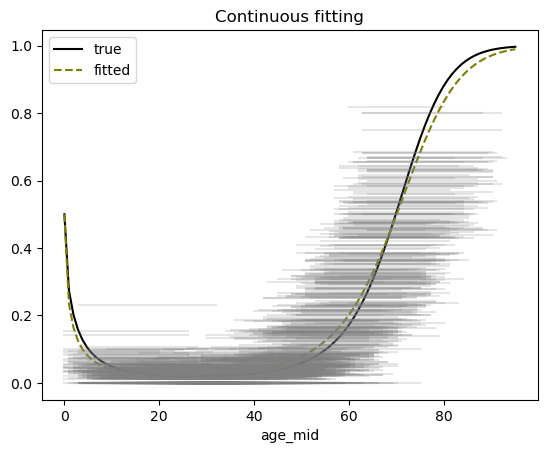

In [62]:
df_pred_cont = pd.DataFrame(dict(age_mid=np.linspace(low_age, high_age, 101)))
df_pred_cont["cov1"] = func1(df_pred_cont["age_mid"])
df_pred_cont["cov2"] = func2(df_pred_cont["age_mid"])
df_pred_cont["cov3"] = func3(df_pred_cont["age_mid"])
df_pred_cont = model_cont.predict(df_pred_cont)
df_pred_cont["p_true"] = expit_death_rate_function(
    df_pred_cont["age_mid"], c1=c1
)

fig, ax = plt.subplots()
ax.plot(
    df_pred_cont["age_mid"], df_pred_cont["p_true"], color="k", label="true"
)
ax.plot(
    df_pred_cont["age_mid"],
    df_pred_cont["p"],
    color="olive",
    linestyle="--",
    label="fitted",
)
ax.legend()
ax.set_xlabel("age_mid")
plt.title("Continuous fitting")

for _, row in df.iterrows():
    ax.plot(
        [row["age_start"], row["age_end"]],
        [row["obs"]] * 2,
        color="grey",
        alpha=0.2,
    )

Text(0.5, 1.0, 'Continuous v discrete fitting')

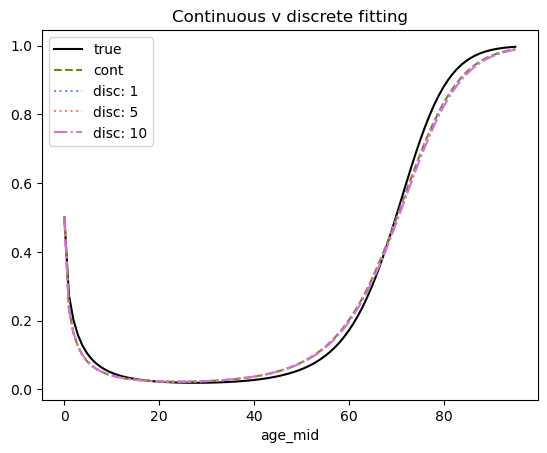

In [67]:
fig, ax = plt.subplots()
ax.plot(
    df_pred_cont["age_mid"], df_pred_cont["p_true"], color="k", label="true"
)
ax.plot(
    df_pred_cont["age_mid"],
    df_pred_cont["p"],
    color="olive",
    linestyle="--",
    label="cont",
)
ax.plot(
    df_pred["age_mid"],
    df_pred["p"],
    color="cornflowerblue",
    linestyle="dotted",
    label="disc: 1",
)
ax.plot(
    df_pred5["age_mid"],
    df_pred5["p"],
    color="salmon",
    linestyle="dotted",
    label="disc: 5",
)
ax.plot(
    df_pred["age_mid"],
    df_pred10["p"],
    color="orchid",
    linestyle="dashdot",
    label="disc: 10",
)
ax.legend()
ax.set_xlabel("age_mid")
plt.title("Continuous v discrete fitting")
# plt.yscale("log")

# for _, row in df.iterrows():
#     ax.plot([row["age_start"], row["age_end"]], [row["obs"]]*2, color="grey", alpha=0.2)

Text(0.5, 1.0, 'Continuous v discrete fitting - logit')

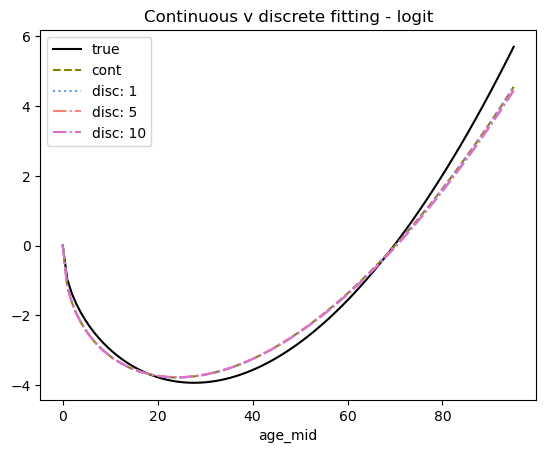

In [68]:
from scipy.special import logit

fig, ax = plt.subplots()
ax.plot(
    df_pred_cont["age_mid"],
    logit(df_pred_cont["p_true"]),
    color="k",
    label="true",
)
ax.plot(
    df_pred_cont["age_mid"],
    logit(df_pred_cont["p"]),
    color="olive",
    linestyle="--",
    label="cont",
)
ax.plot(
    df_pred["age_mid"],
    logit(df_pred["p"]),
    color="cornflowerblue",
    linestyle="dotted",
    label="disc: 1",
)
ax.plot(
    df_pred["age_mid"],
    logit(df_pred5["p"]),
    color="salmon",
    linestyle="dashdot",
    label="disc: 5",
)
ax.plot(
    df_pred["age_mid"],
    logit(df_pred10["p"]),
    color="orchid",
    linestyle="dashdot",
    label="disc: 10",
)
ax.legend()
ax.set_xlabel("age_mid")
plt.title("Continuous v discrete fitting - logit")

In [69]:
print(
    f"This is the MSE for discrete-uniform fitting with 1 spacing: {mean_squared_error(df_pred["p"], df_pred["p_true"])}"
)
print(
    f"This is the MSE for discrete-uniform fitting with 5 spacing: {mean_squared_error(df_pred5["p"], df_pred["p_true"])}"
)
print(
    f"This is the MSE for discrete-uniform fitting with 10 spacing: {mean_squared_error(df_pred10["p"], df_pred["p_true"])}"
)
print(
    f"This is the MSE for continuous fitting: {mean_squared_error(df_pred_cont["p"], df_pred["p_true"])}"
)

This is the MSE for discrete-uniform fitting with 1 spacing: 0.000486714342263518
This is the MSE for discrete-uniform fitting with 5 spacing: 0.0005664660413762588
This is the MSE for discrete-uniform fitting with 10 spacing: 0.00062051486401212
This is the MSE for continuous fitting: 0.00048637993449083454


In [70]:
print(
    f"This is the MAE for discrete-uniform fitting with 1 spacing: {mean_absolute_error(df_pred["p"], df_pred["p_true"])}"
)
print(
    f"This is the MAE for discrete-uniform fitting with 5 spacing: {mean_absolute_error(df_pred5["p"], df_pred["p_true"])}"
)
print(
    f"This is the MAE for discrete-uniform fitting with 10 spacing: {mean_absolute_error(df_pred10["p"], df_pred["p_true"])}"
)
print(
    f"This is the MAE for continuous fitting: {mean_absolute_error(df_pred_cont["p"], df_pred["p_true"])}"
)

This is the MAE for discrete-uniform fitting with 1 spacing: 0.01744943940143206
This is the MAE for discrete-uniform fitting with 5 spacing: 0.01832459551690132
This is the MAE for discrete-uniform fitting with 10 spacing: 0.018797664369963173
This is the MAE for continuous fitting: 0.017447987808207804


Todo for tomorrow:
1. Separate data process from rest of estimation
2. Start to come up with a table that has all the information immediately above